#**install Go**

In [ ]:
# install Go
!wget https://go.dev/dl/go1.22.5.linux-amd64.tar.gz
!rm -rf /usr/local/go
!tar -C /usr/local -xzf go1.22.5.linux-amd64.tar.gz

# set Go path
import os
os.environ["PATH"] += ":/usr/local/go/bin"

# check installation
!go version

--2026-03-30 07:55:34--  https://go.dev/dl/go1.22.5.linux-amd64.tar.gz
Resolving go.dev (go.dev)... 216.239.36.21, 216.239.38.21, 216.239.34.21, ...
Connecting to go.dev (go.dev)|216.239.36.21|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://dl.google.com/go/go1.22.5.linux-amd64.tar.gz [following]
--2026-03-30 07:55:34--  https://dl.google.com/go/go1.22.5.linux-amd64.tar.gz
Resolving dl.google.com (dl.google.com)... 172.253.122.136, 172.253.122.91, 172.253.122.93, ...
Connecting to dl.google.com (dl.google.com)|172.253.122.136|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 68972532 (66M) [application/x-gzip]
Saving to: ‘go1.22.5.linux-amd64.tar.gz’

go1.22.5.linux-amd6 100%[===================>]  65.78M   181MB/s    in 0.4s    

2026-03-30 07:55:34 (181 MB/s) - ‘go1.22.5.linux-amd64.tar.gz’ saved [68972532/68972532]

go version go1.22.5 linux/amd64


#**upload dataset : germany**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving NGDS_CO2_Germany.csv to NGDS_CO2_Germany.csv


In [ ]:
%%writefile main.go
package main

import (
	"encoding/csv"
	"fmt"
	"os"
)

func main() {

	file, err := os.Open("NGDS_CO2_Germany.csv")
	if err != nil {
		fmt.Println(err)
		return
	}
	defer file.Close()

	reader := csv.NewReader(file)

	records, err := reader.ReadAll()
	if err != nil {
		fmt.Println(err)
		return
	}

	fmt.Println("Number of rows:", len(records))

	// print first 5 rows
	for i := 0; i < 5 && i < len(records); i++ {
		fmt.Println(records[i])
	}
}

Writing main.go


In [ ]:
!go run main.go

Number of rows: 54
[Country Name Country Code Indicator Name Indicator Code Year CO2_Mt_CO2e]
[Germany DEU Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e) EN.GHG.CO2.MT.CE.AR5 1970 1084.1188]
[Germany DEU Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e) EN.GHG.CO2.MT.CE.AR5 1971 1077.0031]
[Germany DEU Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e) EN.GHG.CO2.MT.CE.AR5 1972 1104.9335]
[Germany DEU Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e) EN.GHG.CO2.MT.CE.AR5 1973 1157.3697]


#**clean and prepare datset**

* ignore unnecessary columns
* convert values to numeric format
* store data into arrays

In [ ]:
%%writefile clean.go
package main

import (
	"encoding/csv"
	"fmt"
	"os"
	"strconv"
)

func main() {

	file, err := os.Open("NGDS_CO2_Germany.csv")
	if err != nil {
		fmt.Println(err)
		return
	}
	defer file.Close()

	reader := csv.NewReader(file)
	records, err := reader.ReadAll()

	if err != nil {
		fmt.Println(err)
		return
	}

	var years []float64
	var co2 []float64

	// skip header row
	for i := 1; i < len(records); i++ {

		year, _ := strconv.ParseFloat(records[i][4], 64)
		emission, _ := strconv.ParseFloat(records[i][5], 64)

		years = append(years, year)
		co2 = append(co2, emission)
	}

	fmt.Println("Total cleaned records:", len(years))

	fmt.Println("\nFirst 5 cleaned values:")

	for i := 0; i < 5; i++ {
		fmt.Println("Year:", years[i], "CO2:", co2[i])
	}
}

Writing clean.go


In [ ]:
!go run clean.go

Total cleaned records: 53

First 5 cleaned values:
Year: 1970 CO2: 1084.1188
Year: 1971 CO2: 1077.0031
Year: 1972 CO2: 1104.9335
Year: 1973 CO2: 1157.3697
Year: 1974 CO2: 1122.1624


#**build regression model**

In [ ]:
%%writefile regression.go
package main

import (
	"encoding/csv"
	"fmt"
	"os"
	"strconv"
)

func main() {

	file, _ := os.Open("NGDS_CO2_Germany.csv")
	defer file.Close()

	reader := csv.NewReader(file)
	records, _ := reader.ReadAll()

	var x []float64
	var y []float64

	for i := 1; i < len(records); i++ {

		year, _ := strconv.ParseFloat(records[i][4], 64)
		co2, _ := strconv.ParseFloat(records[i][5], 64)

		x = append(x, year)
		y = append(y, co2)
	}

	n := float64(len(x))

	var sumX, sumY, sumXY, sumX2 float64

	for i := 0; i < len(x); i++ {

		sumX += x[i]
		sumY += y[i]
		sumXY += x[i] * y[i]
		sumX2 += x[i] * x[i]
	}

	// calculate slope (m)
	m := (n*sumXY - sumX*sumY) / (n*sumX2 - sumX*sumX)

	// calculate intercept (b)
	b := (sumY - m*sumX) / n

	fmt.Println("Regression Model:")
	fmt.Println("CO2 =", m, "* Year +", b)

	// example prediction
	predYear := 2030.0
	prediction := m*predYear + b

	fmt.Println("\nPredicted CO2 emission in 2030:", prediction)
}

Writing regression.go


In [ ]:
!go run regression.go

Regression Model:
CO2 = -9.262691219151886 * Year + 19422.825948898862

Predicted CO2 emission in 2030: 619.5627740205346


#**Compute MSE**

In [ ]:
%%writefile evaluation.go
package main

import (
	"encoding/csv"
	"fmt"
	"os"
	"strconv"
)

func main() {

	file, _ := os.Open("NGDS_CO2_Germany.csv")
	defer file.Close()

	reader := csv.NewReader(file)
	records, _ := reader.ReadAll()

	var x []float64
	var y []float64

	for i := 1; i < len(records); i++ {

		year, _ := strconv.ParseFloat(records[i][4], 64)
		co2, _ := strconv.ParseFloat(records[i][5], 64)

		x = append(x, year)
		y = append(y, co2)
	}

	n := float64(len(x))

	var sumX, sumY, sumXY, sumX2 float64

	for i := 0; i < len(x); i++ {

		sumX += x[i]
		sumY += y[i]
		sumXY += x[i] * y[i]
		sumX2 += x[i] * x[i]
	}

	m := (n*sumXY - sumX*sumY) / (n*sumX2 - sumX*sumX)
	b := (sumY - m*sumX) / n

	var mse float64

	for i := 0; i < len(x); i++ {

		predicted := m*x[i] + b
		error := y[i] - predicted

		mse += error * error
	}

	mse = mse / n

	fmt.Println("Mean Squared Error:", mse)
}

Writing evaluation.go


In [ ]:
!go run evaluation.go

Mean Squared Error: 1480.9769961415568


#**analyse trends**

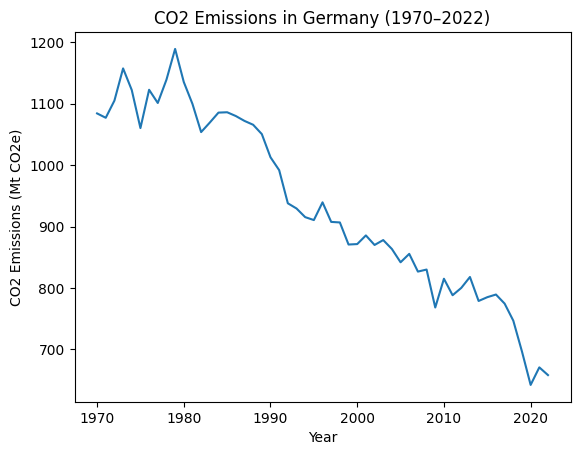

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("NGDS_CO2_Germany.csv")

plt.figure()
plt.plot(df["Year"], df["CO2_Mt_CO2e"])

plt.title("CO2 Emissions in Germany (1970–2022)")
plt.xlabel("Year")
plt.ylabel("CO2 Emissions (Mt CO2e)")

plt.show()